In [7]:
with open("/content/drive/MyDrive/sombra.txt") as archivo:
  discurso=archivo.read()

In [8]:
print(discurso[:500])

La sombra
Un cuento de Hans Christian Andersen
¡Es terrible lo que quema el sol en los países cálidos! Las gentes se vuelven muy morenas, y en los países más tórridos su piel se quema hasta hacerse negra. Pero ahora vais a oír la historia de un sabio que de los países fríos pasó sin transición a los cálidos, y creía que podría seguir viviendo allí como en su tierra. Muy pronto tuvo que cambiar de opinión. Durante el día tuvo que seguir el ejemplo de todas las personas juiciosas: permanecer en ca


In [9]:
len(discurso)

24405

In [10]:
discurso = discurso.lower()
discurso = discurso.replace(",","")
discurso = discurso.replace(";","")
discurso = discurso.replace(".","")
discurso = discurso.replace(".","")
discurso = discurso.replace(":","")

In [11]:
palabras = discurso.split()

In [12]:
palabras[:20]

['la',
 'sombra',
 'un',
 'cuento',
 'de',
 'hans',
 'christian',
 'andersen',
 '¡es',
 'terrible',
 'lo',
 'que',
 'quema',
 'el',
 'sol',
 'en',
 'los',
 'países',
 'cálidos!',
 'las']

In [13]:
import pandas as pd
import numpy as np

palabras_array=np.array(palabras)

In [14]:
longitudes=np.array([len(palabra) for palabra in palabras_array])

print("promedio",np.mean(longitudes))
print("mediana",np.median(longitudes))
print("minimo",np.min(longitudes))
print("max",np.max(longitudes))

promedio 4.385190217391305
mediana 4.0
minimo 1
max 15


In [15]:
df = pd.DataFrame(
    {
        "palabra":palabras
    }

)
df.head()

,palabra
0,la
1,sombra
2,un
3,cuento
4,de


In [16]:
df["longitud"]=df["palabra"].str.len()
df.head(10)

,palabra,longitud
0,la,2
1,sombra,6
2,un,2
3,cuento,6
4,de,2
5,hans,4
6,christian,9
7,andersen,8
8,¡es,3
9,terrible,8


In [17]:
frecuencias=df["palabra"].value_counts()
print(frecuencias.head(20))

palabra
la        189
de        161
que       158
y         148
en        113
el        101
a          85
-          73
lo         72
se         67
sombra     61
no         61
me         48
pero       43
las        42
una        41
un         41
los        38
su         37
por        36
Name: count, dtype: int64


In [62]:
stopwords = [
    "el","que","en","de","del","y","a","los","lo","la","\"","un","te",
    "no","se","si","eso","para","le","una","su","o","“","es","son","por","más",
    "al","así","este","con","-","las","me","mi","pues","pero","yo","tan","ella",
    "ya","ha","sin","era","como","he","sus","mucho","tengo","cuando","había","muy",
    "estaba"
]

In [63]:
df_limpio = df[~df["palabra"].isin(stopwords)]

In [64]:
frecuencias = df_limpio["palabra"].value_counts()
frecuencias.head(20)

,count
palabra,
sombra,61
sabio,24
usted,24
todo,23
-dijo,22
hombre,18
princesa,15
ser,15
balcón,14


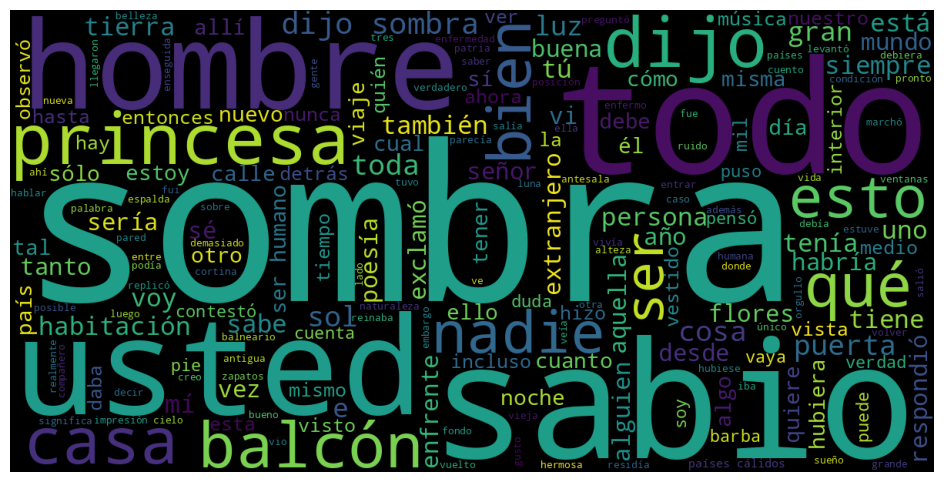

In [71]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto_limpio = " ".join(df_limpio["palabra"])

wordcloud = WordCloud(width=1200, height=600, background_color="black").generate(texto_limpio)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()